# Final Swedish Sentiment Pipeline: `SENT_ORTH_DIV_PREMIUM`

This notebook produces the Sweden sentiment analysis used in this thesis. The selected final index is `SENT_ORTH_DIV_PREMIUM`, and the notebook also estimates the same predictive tests with the non-orthogonalized `SENT_DIV_PREMIUM` to show how much the macro-orthogonalization step changes the empirical results. A third discussion-layer index, `SENT_ORTH_SIBLEY_DIV_PREMIUM`, uses the same seven sentiment proxies but residualizes them against a broader Sibley-style macro-financial control set before PCA.

Methodological scope:

- Build the Swedish six-proxy sentiment index using the implemented Swedish-paper logic on the available sample.
- Add the Baker-Wurgler-style dividend-premium proxy as a seventh proxy.
- Use the macro-orthogonalized version, `SENT_ORTH_DIV_PREMIUM`, as the final sentiment measure.
- Retain the raw non-orthogonalized `SENT_DIV_PREMIUM` only as a comparison specification.
- Add `SENT_ORTH_SIBLEY_DIV_PREMIUM` as a discussion robustness index for the Sibley et al. business-cycle critique.
- Form portfolios using lagged firm characteristics and evaluate subsequent returns.
- Run predictive regressions over 1-, 3-, 6-, and 12-month compounded return horizons.
- Report HAC/Newey-West inference as the main inference and moving-block bootstrap inference as robustness.

The broader master notebook remains the audit and model-comparison notebook. This notebook produces the streamlined thesis outputs for the chosen specification and its direct discussion-layer comparisons.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "nordic_sentiment" / "config" / "sources.yml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
PACKAGE_ROOT = REPO_ROOT / "nordic_sentiment" / "src_final"
if str(PACKAGE_ROOT) in sys.path:
    sys.path.remove(str(PACKAGE_ROOT))
sys.path.insert(0, str(PACKAGE_ROOT))

import nordic_sentiment as _nordic_sentiment_package

package_file = Path(_nordic_sentiment_package.__file__).resolve()
if "src_final" not in str(package_file):
    raise RuntimeError(f"FINAL_SENTIMENT_SWEDEN must import from src_final, got {package_file}")

OUTPUT_DIR = REPO_ROOT / "outputs" / "final_sentiment_sweden"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_FULL_PIPELINE = True
SAVE_OUTPUTS = True
BOOTSTRAP_REPETITIONS = 1_000
BOOTSTRAP_SEED = 20260510
PREDICTIVE_HORIZONS = (1, 3, 6, 12)
MAIN_SENTIMENT_REGRESSOR = "SENT_ORTH_DIV_PREMIUM_lag"
CONTROL_COLUMNS = ["RMRF", "SMB", "HML", "UMD"]
SENTIMENT_SPECS = [
    {
        "sentiment_index_family": "dividend_premium_macro_adjusted_fixed_pca",
        "sentiment_index_label": "SENT_ORTH_DIV_PREMIUM",
        "sentiment_level_column": "SENT_ORTH_DIV_PREMIUM",
        "sentiment_regressor": "SENT_ORTH_DIV_PREMIUM_lag",
        "macro_orthogonalized_flag": True,
        "main_specification_flag": True,
    },
    {
        "sentiment_index_family": "dividend_premium_sibley_macro_adjusted_fixed_pca",
        "sentiment_index_label": "SENT_ORTH_SIBLEY_DIV_PREMIUM",
        "sentiment_level_column": "SENT_ORTH_SIBLEY_DIV_PREMIUM",
        "sentiment_regressor": "SENT_ORTH_SIBLEY_DIV_PREMIUM_lag",
        "macro_orthogonalized_flag": True,
        "main_specification_flag": False,
    },
    {
        "sentiment_index_family": "dividend_premium_unadjusted_fixed_pca",
        "sentiment_index_label": "SENT_DIV_PREMIUM",
        "sentiment_level_column": "SENT_DIV_PREMIUM",
        "sentiment_regressor": "SENT_DIV_PREMIUM_lag",
        "macro_orthogonalized_flag": False,
        "main_specification_flag": False,
    },
]
SENTIMENT_REGRESSORS = [spec["sentiment_regressor"] for spec in SENTIMENT_SPECS]
SENTIMENT_LEVEL_COLUMNS = [spec["sentiment_level_column"] for spec in SENTIMENT_SPECS]

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

REPO_ROOT, OUTPUT_DIR

(PosixPath('/Users/jonathancarlsen/Library/CloudStorage/OneDrive-CBS-CopenhagenBusinessSchool/3. år/Bachelor/vs_inference'),
 PosixPath('/Users/jonathancarlsen/Library/CloudStorage/OneDrive-CBS-CopenhagenBusinessSchool/3. år/Bachelor/vs_inference/outputs/final_sentiment_sweden'))

In [ ]:
from nordic_sentiment import load_project_configs
from nordic_sentiment.portfolios.sorts import (
    add_lagged_sort_signals,
    build_binary_flag_portfolios,
    build_equal_weight_portfolios,
    build_forward_compounded_return_windows,
    build_lagged_sort_signal_coverage,
    build_long_short_spread,
    build_spread_between_portfolios,
)
from nordic_sentiment.regressions import run_ols_with_hac_and_bootstrap
from nordic_sentiment.sentiment.sweden import (
    SIBLEY_MACRO_CONTROL_COLUMNS,
    apply_ed_ratio_availability_to_paper_spec,
    apply_ipo_return_availability_to_paper_spec,
    apply_macro_control_availability_to_paper_spec,
    assert_sweden_paper_spec_ready,
    build_sweden_dividend_premium_proxy_source,
    build_sweden_ipo_return_table,
    build_sweden_macro_controls_monthly,
    build_sweden_sibley_macro_controls_monthly,
    build_sweden_sentiment_index_with_dividend_premium,
    build_sweden_sentiment_proxy_source,
    default_sweden_paper_spec_audit,
)
from nordic_sentiment.sweden_pipeline import (
    build_sweden_artifacts,
    load_sweden_raw_data,
    stage_sweden_raw_data,
)

configs = load_project_configs()
configs.sources.keys()

## Helper Functions

These helpers are intentionally limited to final-output construction. They save compact tables for this thesis and keep broad diagnostics in the master notebook.

In [3]:
def save_table(frame: pd.DataFrame, name: str) -> pd.DataFrame:
    if SAVE_OUTPUTS:
        frame.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)
    return frame


def save_figure(name: str) -> None:
    if SAVE_OUTPUTS:
        plt.savefig(OUTPUT_DIR / f"{name}.png", dpi=160, bbox_inches="tight")


def hac_only(frame: pd.DataFrame) -> pd.DataFrame:
    bootstrap_columns = [
        "bootstrap_std_error",
        "bootstrap_t_stat",
        "bootstrap_p_value",
        "bootstrap_repetitions",
        "bootstrap_block_length",
        "bootstrap_seed",
        "bootstrap_valid_repetitions",
    ]
    return frame.drop(columns=bootstrap_columns, errors="ignore") if isinstance(frame, pd.DataFrame) else frame


def concat_non_empty(frames: list[pd.DataFrame]) -> pd.DataFrame:
    non_empty = [frame for frame in frames if frame is not None and not frame.empty]
    return pd.concat(non_empty, ignore_index=True) if non_empty else pd.DataFrame()


def numeric_summary(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for column in columns:
        if column not in frame.columns:
            continue
        values = pd.to_numeric(frame[column], errors="coerce").astype("float64")
        rows.append(
            {
                "variable": column,
                "count": int(values.notna().sum()),
                "mean": values.mean(),
                "std": values.std(),
                "min": values.min(),
                "p05": values.quantile(0.05),
                "median": values.quantile(0.50),
                "p95": values.quantile(0.95),
                "max": values.max(),
                "missing_share": values.isna().mean(),
            }
        )
    return pd.DataFrame(rows)


def run_predictive_regression(
    frame: pd.DataFrame,
    *,
    y_col: str,
    x_cols: list[str],
    return_horizon_months: int,
) -> pd.DataFrame:
    return run_ols_with_hac_and_bootstrap(
        frame,
        y_col,
        x_cols,
        min_hac_lags=max(int(return_horizon_months) - 1, 0),
        return_horizon_months=int(return_horizon_months),
        bootstrap_repetitions=BOOTSTRAP_REPETITIONS,
        bootstrap_seed=BOOTSTRAP_SEED,
    )


def run_regression_suite(
    panel: pd.DataFrame,
    *,
    y_col: str,
    group_columns: list[str],
    result_set: str,
    sentiment_specs: list[dict[str, object]] | None = None,
) -> pd.DataFrame:
    if panel is None or panel.empty:
        return pd.DataFrame()
    specs = sentiment_specs or SENTIMENT_SPECS
    rows = []
    for spec in specs:
        sentiment_regressor = str(spec["sentiment_regressor"])
        if sentiment_regressor not in panel.columns:
            continue
        x_cols = [sentiment_regressor, *[column for column in CONTROL_COLUMNS if column in panel.columns]]
        for group_key, group in panel.groupby(group_columns, dropna=False, sort=True):
            if not isinstance(group_key, tuple):
                group_key = (group_key,)
            metadata = dict(zip(group_columns, group_key))
            horizon = int(metadata.get("return_horizon_months", 1))
            result = run_predictive_regression(group, y_col=y_col, x_cols=x_cols, return_horizon_months=horizon)
            for column, value in reversed(list(metadata.items())):
                result.insert(0, column, value)
            result.insert(0, "result_set", result_set)
            result.insert(1, "sentiment_index_family", spec["sentiment_index_family"])
            result.insert(2, "sentiment_index_label", spec["sentiment_index_label"])
            result.insert(3, "sentiment_regressor", sentiment_regressor)
            result.insert(4, "macro_orthogonalized_flag", bool(spec["macro_orthogonalized_flag"]))
            result.insert(5, "main_specification_flag", bool(spec["main_specification_flag"]))
            result.insert(6, "dependent_variable", y_col)
            result.insert(7, "model", f"{y_col}_on_{sentiment_regressor}_and_factors")
            rows.append(result)
    out = concat_non_empty(rows)
    return add_interpretation_columns(out)


def add_interpretation_columns(results: pd.DataFrame) -> pd.DataFrame:
    if results is None or results.empty:
        return pd.DataFrame(results)
    out = results.copy()
    sentiment_term = out["term"].eq(out["sentiment_regressor"])
    out["sentiment_term_flag"] = sentiment_term
    out["expected_coef_sign"] = np.nan
    if "return_leg" in out.columns:
        out.loc[sentiment_term & out["return_leg"].isin(["directional_spread", "long_leg"]), "expected_coef_sign"] = -1.0
    else:
        out.loc[sentiment_term, "expected_coef_sign"] = -1.0
    out["expected_signed_t_stat"] = out["expected_coef_sign"] * pd.to_numeric(out["t_stat"], errors="coerce")
    out["expected_signed_bootstrap_t_stat"] = out["expected_coef_sign"] * pd.to_numeric(
        out.get("bootstrap_t_stat"), errors="coerce"
    )
    out["theory_consistent_sign"] = out["expected_signed_t_stat"].gt(0)
    out["theory_consistent_hac_5pct"] = out["expected_signed_t_stat"].ge(1.96)
    out["theory_consistent_bootstrap_5pct"] = out["expected_signed_bootstrap_t_stat"].ge(1.96)
    out["mechanical_overlap_warning"] = out.get("sort_variable", pd.Series(pd.NA, index=out.index)).isin(["NON_D_PAYER", "BE_ME"])
    out["mechanical_overlap_note"] = np.where(
        out["mechanical_overlap_warning"],
        "Interpret cautiously: dividend-premium sentiment indices contain information related to dividend status and valuation.",
        "",
    )
    return out


def summarize_sentiment_terms(results: pd.DataFrame, group_columns: list[str]) -> pd.DataFrame:
    if results is None or results.empty:
        return pd.DataFrame()
    terms = results.loc[results["term"].eq(results["sentiment_regressor"])].copy()
    if terms.empty:
        return terms
    return (
        terms.groupby(group_columns, dropna=False)
        .agg(
            model_count=("term", "size"),
            mean_coef=("coef", "mean"),
            mean_hac_t=("t_stat", "mean"),
            mean_expected_signed_t=("expected_signed_t_stat", "mean"),
            mean_bootstrap_t=("bootstrap_t_stat", "mean"),
            mean_expected_signed_bootstrap_t=("expected_signed_bootstrap_t_stat", "mean"),
            hac_theory_consistent_5pct_share=("theory_consistent_hac_5pct", "mean"),
            bootstrap_theory_consistent_5pct_share=("theory_consistent_bootstrap_5pct", "mean"),
            mean_r2=("r2", "mean"),
            min_n_obs=("n_obs", "min"),
            median_n_obs=("n_obs", "median"),
        )
        .reset_index()
    )


def sentiment_comparison_summary(results: pd.DataFrame, group_columns: list[str]) -> pd.DataFrame:
    summary = summarize_sentiment_terms(results, [*group_columns, "sentiment_index_label", "sentiment_regressor", "macro_orthogonalized_flag", "main_specification_flag"])
    if summary.empty:
        return summary
    return summary.sort_values([*group_columns, "main_specification_flag"], ascending=[*[True] * len(group_columns), False]).reset_index(drop=True)

## Build Canonical Sweden Artifacts

This cell runs the production pipeline once. The resulting artifacts contain the cleaned equity universe, corrected returns, capped fundamentals, characteristics, factors, IPO proxies, macro controls, and sentiment proxy mart used below.

In [4]:
if not RUN_FULL_PIPELINE:
    raise RuntimeError("Set RUN_FULL_PIPELINE = True to execute the final thesis pipeline.")

raw = load_sweden_raw_data(configs)
staged = stage_sweden_raw_data(raw)

macro_controls = build_sweden_macro_controls_monthly(
    cpi=raw.macro_control_cpi,
    ppi=raw.macro_control_ppi,
    ip=raw.macro_control_ip,
    em=raw.macro_control_em,
)
ipo_returns = build_sweden_ipo_return_table(staged.ipo_offers, staged.daily_prices)

paper_spec = default_sweden_paper_spec_audit()
paper_spec = apply_macro_control_availability_to_paper_spec(paper_spec, macro_controls)
paper_spec = apply_ipo_return_availability_to_paper_spec(paper_spec, ipo_returns)
paper_spec = apply_ed_ratio_availability_to_paper_spec(paper_spec, raw.economic_consumer_sentiment)
assert_sweden_paper_spec_ready(paper_spec)

proxy_source = build_sweden_sentiment_proxy_source(
    economic_consumer_sentiment=raw.economic_consumer_sentiment,
    daily_prices=staged.daily_prices,
    quarterly_fundamentals=staged.quarterly_fundamentals,
    ipo_returns=ipo_returns,
    paper_spec=paper_spec,
)

artifacts = build_sweden_artifacts(
    staged,
    sentiment_paper_spec=paper_spec,
    sentiment_proxy_source=proxy_source,
    macro_controls_monthly=macro_controls,
)

artifact_shapes = pd.DataFrame(
    [
        {"artifact": name, "rows": len(frame), "columns": len(frame.columns)}
        for name, frame in [
            ("fct_market_monthly", artifacts.fct_market_monthly),
            ("mart_characteristics_monthly", artifacts.mart_characteristics_monthly),
            ("fct_factor_monthly", artifacts.fct_factor_monthly),
            ("mart_sentiment_proxy_monthly", artifacts.mart_sentiment_proxy_monthly),
            ("fct_macro_controls_monthly", artifacts.fct_macro_controls_monthly),
        ]
    ]
)
display(artifact_shapes)
save_table(artifact_shapes, "artifact_shapes")

KeyboardInterrupt: 

## Construct Dividend-Premium Sentiment Indices

The final index adds `DIV_PREMIUM` as a seventh sentiment proxy and uses the macro-orthogonalized index value. `DIV_PREMIUM` is constructed as the log difference between value-weighted market-to-book ratios of regular dividend payers and non-payers.

The Sibley discussion variant uses the same seven sentiment proxies and PCA construction, but replaces the Swedish-paper macro controls with the broader Sibley-style macro-financial control set before PCA.


In [ ]:
dividend_premium_proxy_source, dividend_premium_proxy_diagnostics = build_sweden_dividend_premium_proxy_source(
    artifacts.mart_characteristics_monthly,
    min_group_count=10,
)

if dividend_premium_proxy_source.empty or dividend_premium_proxy_source["raw_value"].nunique(dropna=True) < 2:
    raise RuntimeError("DIV_PREMIUM proxy has insufficient observations or variation.")

sentiment_proxy_mart_dividend_premium = pd.concat(
    [artifacts.mart_sentiment_proxy_monthly, dividend_premium_proxy_source],
    ignore_index=True,
)

sibley_consumption_path = REPO_ROOT / "Macrocontrols" / "Sibley macros" / "MNA.Q.Y.SE.W0.S1M.S1.D.P31._Z._Z._T.XDC.LR.N .csv"
if not sibley_consumption_path.exists():
    raise FileNotFoundError(f"Missing Sibley consumption macro-control file: {sibley_consumption_path}")
sibley_consumption = pd.read_csv(sibley_consumption_path)

sibley_macro_controls = build_sweden_sibley_macro_controls_monthly(
    cpi=raw.macro_control_cpi,
    ip=raw.macro_control_ip,
    labour_market=raw.macro_control_em,
    consumption=sibley_consumption,
    rates_monthly=artifacts.fct_rate_monthly,
    market_monthly=artifacts.fct_market_monthly,
    daily_prices=artifacts.fct_price_daily,
)

sentiment_monthly, sentiment_annual, sentiment_diagnostics = build_sweden_sentiment_index_with_dividend_premium(
    paper_spec,
    sentiment_proxy_mart_dividend_premium,
    macro_controls=artifacts.fct_macro_controls_monthly,
)

sentiment_sibley_monthly, sentiment_sibley_annual, sentiment_sibley_diagnostics = build_sweden_sentiment_index_with_dividend_premium(
    paper_spec,
    sentiment_proxy_mart_dividend_premium,
    macro_controls=sibley_macro_controls,
    macro_control_columns=SIBLEY_MACRO_CONTROL_COLUMNS,
)

sentiment_monthly = sentiment_monthly.sort_values("month_end_date").reset_index(drop=True)
sentiment_sibley_monthly = sentiment_sibley_monthly.sort_values("month_end_date").reset_index(drop=True)
sentiment_sibley_monthly = sentiment_sibley_monthly.rename(
    columns={
        "SENT_ORTH_DIV_PREMIUM": "SENT_ORTH_SIBLEY_DIV_PREMIUM",
        "RSENT_REEST_DIV_PREMIUM": "RSENT_REEST_SIBLEY_DIV_PREMIUM",
        "sentiment_orth_div_premium": "sentiment_orth_sibley_div_premium",
    }
)
sentiment_sibley_annual = sentiment_sibley_annual.rename(
    columns={
        "SENT_ORTH_DIV_PREMIUM": "SENT_ORTH_SIBLEY_DIV_PREMIUM",
        "RSENT_REEST_DIV_PREMIUM": "RSENT_REEST_SIBLEY_DIV_PREMIUM",
        "sentiment_orth_div_premium": "sentiment_orth_sibley_div_premium",
    }
)

sentiment_panel = sentiment_monthly[["country_code", "month_end_date", "SENT_DIV_PREMIUM", "SENT_ORTH_DIV_PREMIUM"]].copy()
sentiment_panel = sentiment_panel.merge(
    sentiment_sibley_monthly[["country_code", "month_end_date", "SENT_ORTH_SIBLEY_DIV_PREMIUM"]],
    on=["country_code", "month_end_date"],
    how="left",
)
sentiment_panel["month_end_date"] = pd.to_datetime(sentiment_panel["month_end_date"], errors="coerce")
for spec in SENTIMENT_SPECS:
    sentiment_panel[str(spec["sentiment_regressor"])] = sentiment_panel.groupby("country_code")[str(spec["sentiment_level_column"])].shift(1)
    sentiment_panel[f"{spec['sentiment_level_column']}_change"] = sentiment_panel.groupby("country_code")[str(spec["sentiment_level_column"])].diff()

sentiment_panel["ORTH_minus_RAW_DIV_PREMIUM"] = sentiment_panel["SENT_ORTH_DIV_PREMIUM"] - sentiment_panel["SENT_DIV_PREMIUM"]
sentiment_panel["SIBLEY_minus_ORTH_DIV_PREMIUM"] = sentiment_panel["SENT_ORTH_SIBLEY_DIV_PREMIUM"] - sentiment_panel["SENT_ORTH_DIV_PREMIUM"]
sentiment_correlation = sentiment_panel[SENTIMENT_LEVEL_COLUMNS].corr()
sentiment_sibley_correlation = sentiment_panel[["SENT_ORTH_DIV_PREMIUM", "SENT_ORTH_SIBLEY_DIV_PREMIUM"]].corr()

sentiment_summary_columns = []
for spec in SENTIMENT_SPECS:
    sentiment_summary_columns.extend(
        [
            str(spec["sentiment_level_column"]),
            str(spec["sentiment_regressor"]),
            f"{spec['sentiment_level_column']}_change",
        ]
    )
sentiment_summary_columns.extend(["ORTH_minus_RAW_DIV_PREMIUM", "SIBLEY_minus_ORTH_DIV_PREMIUM"])
sentiment_summary = numeric_summary(sentiment_panel, sentiment_summary_columns)
sentiment_sibley_summary = numeric_summary(
    sentiment_panel,
    [
        "SENT_ORTH_DIV_PREMIUM",
        "SENT_ORTH_SIBLEY_DIV_PREMIUM",
        "SENT_ORTH_DIV_PREMIUM_lag",
        "SENT_ORTH_SIBLEY_DIV_PREMIUM_lag",
        "SIBLEY_minus_ORTH_DIV_PREMIUM",
    ],
)

save_table(sibley_macro_controls, "final_sibley_macro_controls_monthly")
save_table(sentiment_monthly, "final_sentiment_monthly")
save_table(sentiment_annual, "final_sentiment_annual")
save_table(sentiment_sibley_monthly, "final_sentiment_sibley_macro_monthly")
save_table(sentiment_sibley_annual, "final_sentiment_sibley_macro_annual")
save_table(sentiment_panel, "final_sentiment_regression_panel_monthly")
save_table(sentiment_correlation.reset_index().rename(columns={"index": "variable"}), "final_sentiment_raw_vs_orth_correlation")
save_table(sentiment_sibley_correlation.reset_index().rename(columns={"index": "variable"}), "final_sentiment_sibley_macro_correlation")
save_table(dividend_premium_proxy_source, "final_dividend_premium_proxy_source")
save_table(dividend_premium_proxy_diagnostics, "final_dividend_premium_proxy_diagnostics")
save_table(sentiment_summary, "final_sentiment_numeric_summary")
save_table(sentiment_sibley_summary, "final_sentiment_sibley_macro_numeric_summary")
for name, frame in sentiment_diagnostics.items():
    if name in {
        "lead_lag_selection",
        "stage2_selected_variables",
        "stage2_reestimated_weights",
        "stage3_selected_variables",
        "stage3_weighted_coefficients",
        "stage3_eigenvalues",
        "stage3_sample_stats",
        "stage3_macro_controls",
        "macro_residualization_coefficients",
        "dividend_premium_proxy_role",
    }:
        save_table(frame, f"final_sentiment_diagnostic_{name}")
for name, frame in sentiment_sibley_diagnostics.items():
    if name in {
        "lead_lag_selection",
        "stage2_selected_variables",
        "stage2_reestimated_weights",
        "stage3_selected_variables",
        "stage3_weighted_coefficients",
        "stage3_eigenvalues",
        "stage3_sample_stats",
        "stage3_macro_controls",
        "macro_residualization_coefficients",
        "dividend_premium_proxy_role",
    }:
        save_table(frame, f"final_sentiment_sibley_macro_diagnostic_{name}")

display(sentiment_summary)
display(sentiment_correlation)
display(sentiment_sibley_summary)
display(sentiment_sibley_correlation)
display(sentiment_diagnostics.get("lead_lag_selection", pd.DataFrame()))
display(sentiment_diagnostics.get("stage3_weighted_coefficients", pd.DataFrame()))
display(sentiment_sibley_diagnostics.get("stage3_weighted_coefficients", pd.DataFrame()))


,variable,count,mean,std,min,p05,median,p95,max,missing_share
0,SENT_ORTH_DIV_PREMIUM,289,-0.013773,0.557983,-1.332699,-0.839562,-0.042867,0.853664,2.361472,0.033445
1,SENT_ORTH_DIV_PREMIUM_lag,288,-0.014822,0.558669,-1.332699,-0.839776,-0.044292,0.854871,2.361472,0.036789
2,SENT_ORTH_DIV_PREMIUM_change,288,-0.001885,0.355759,-2.163402,-0.511033,-0.012037,0.509672,2.142653,0.036789
3,SENT_ORTH_SIBLEY_DIV_PREMIUM,289,-0.006136,0.530053,-1.287578,-0.718607,-0.029124,0.744447,4.848104,0.033445
4,SENT_ORTH_SIBLEY_DIV_PREMIUM_lag,288,-0.009044,0.528662,-1.287578,-0.718960,-0.031177,0.695087,4.848104,0.036789
5,SENT_ORTH_SIBLEY_DIV_PREMIUM_change,288,0.001840,0.676218,-5.394807,-0.867477,0.010026,0.873538,4.415130,0.036789
6,SENT_DIV_PREMIUM,289,-0.009000,0.518587,-1.378782,-0.669634,-0.006116,0.740645,4.204706,0.033445
7,SENT_DIV_PREMIUM_lag,288,-0.010445,0.518907,-1.378782,-0.669754,-0.009562,0.741126,4.204706,0.036789
8,SENT_DIV_PREMIUM_change,288,0.000966,0.558478,-4.829104,-0.755303,0.043600,0.744020,3.522198,0.036789
9,ORTH_minus_RAW_DIV_PREMIUM,289,-0.004772,0.513123,-1.843234,-0.862781,0.006810,0.808325,1.455173,0.033445


proxy_code,SENT_ORTH_DIV_PREMIUM,SENT_ORTH_SIBLEY_DIV_PREMIUM,SENT_DIV_PREMIUM
proxy_code,,,
SENT_ORTH_DIV_PREMIUM,1.000000,0.466144,0.547724
SENT_ORTH_SIBLEY_DIV_PREMIUM,0.466144,1.000000,0.874460
SENT_DIV_PREMIUM,0.547724,0.874460,1.000000


,variable,count,mean,std,min,p05,median,p95,max,missing_share
0,SENT_ORTH_DIV_PREMIUM,289,-0.013773,0.557983,-1.332699,-0.839562,-0.042867,0.853664,2.361472,0.033445
1,SENT_ORTH_SIBLEY_DIV_PREMIUM,289,-0.006136,0.530053,-1.287578,-0.718607,-0.029124,0.744447,4.848104,0.033445
2,SENT_ORTH_DIV_PREMIUM_lag,288,-0.014822,0.558669,-1.332699,-0.839776,-0.044292,0.854871,2.361472,0.036789
3,SENT_ORTH_SIBLEY_DIV_PREMIUM_lag,288,-0.009044,0.528662,-1.287578,-0.718960,-0.031177,0.695087,4.848104,0.036789
4,SIBLEY_minus_ORTH_DIV_PREMIUM,289,0.007637,0.562643,-1.452458,-0.806552,-0.064373,0.970381,2.486632,0.033445


proxy_code,SENT_ORTH_DIV_PREMIUM,SENT_ORTH_SIBLEY_DIV_PREMIUM
proxy_code,,
SENT_ORTH_DIV_PREMIUM,1.000000,0.466144
SENT_ORTH_SIBLEY_DIV_PREMIUM,0.466144,1.000000


,base_proxy,current_proxy,lagged_proxy,corr_current,corr_lagged,selected_proxy
0,ESI,ESI,ESI_L1,0.004344,0.107350,ESI_L1
1,CCI,CCI,CCI_L1,0.059549,0.128156,CCI_L1
2,TURN,TURN,TURN_L1,0.418035,0.446541,TURN_L1
3,NIPO,NIPO,NIPO_L1,0.170594,0.150577,NIPO
4,RIPO,RIPO,RIPO_L1,0.001228,-0.040549,RIPO
5,ED_RATIO,ED_RATIO,ED_RATIO_L1,0.606947,0.614832,ED_RATIO_L1
6,DIV_PREMIUM,DIV_PREMIUM,DIV_PREMIUM_L1,0.892189,0.890449,DIV_PREMIUM


,variable,Comp1,Comp2,Comp3,Comp4,Comp5,sum
0,rESI_L1,-0.087714,0.150695,-0.008197,0.021334,0.038734,0.114852
1,rCCI_L1,-0.093791,0.146154,0.025726,-0.023191,-0.039232,0.015667
2,rTURN_L1,0.161611,0.062733,-0.017693,0.066396,-0.022834,0.250213
3,rNIPO,-0.010206,-0.023203,0.157282,0.021701,0.004698,0.150271
4,rRIPO,0.003906,0.015249,-0.001255,0.005432,0.040885,0.064218
5,rED_RATIO_L1,0.144511,0.061401,0.030091,-0.039421,0.002654,0.199236
6,rDIV_PREMIUM,0.184506,0.041289,0.009838,-0.027842,0.015787,0.223578


,variable,Comp1,Comp2,Comp3,Comp4,Comp5,sum
0,rESI_L1,0.063561,0.154916,0.037894,0.011000,0.038176,0.305547
1,rCCI_L1,0.082222,0.151964,0.018751,-0.012732,-0.042577,0.197629
2,rTURN_L1,-0.011387,-0.052259,0.135232,0.059899,-0.013286,0.118200
3,rNIPO,0.087112,-0.059179,0.065248,-0.108340,0.007822,-0.007336
4,rRIPO,0.005533,0.006621,0.013650,0.014607,0.046884,0.087295
5,rED_RATIO_L1,0.174483,-0.034233,-0.032876,0.029492,0.000186,0.137052
6,rDIV_PREMIUM,0.170415,-0.069506,-0.014281,0.030753,-0.000295,0.117087


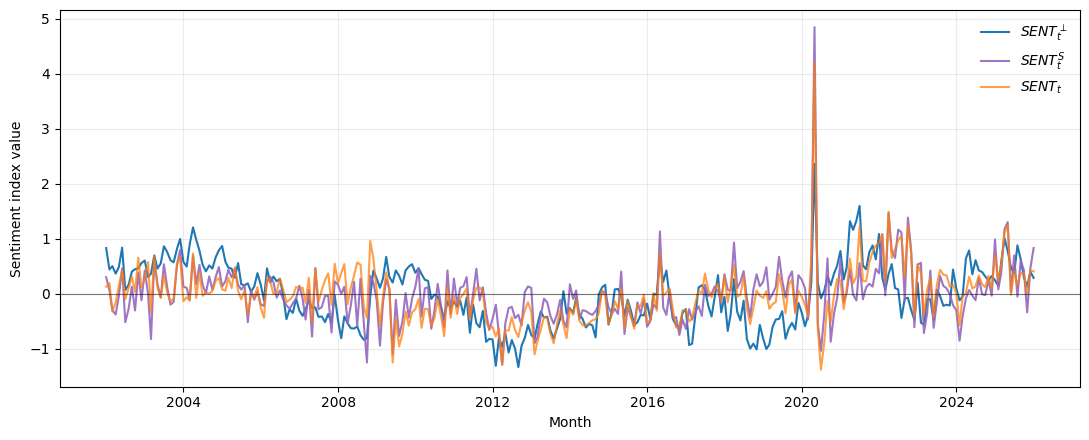

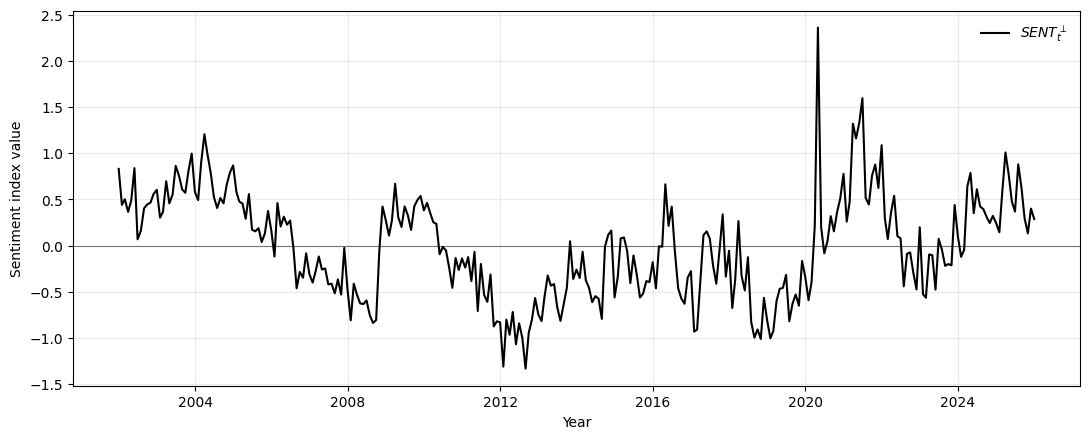

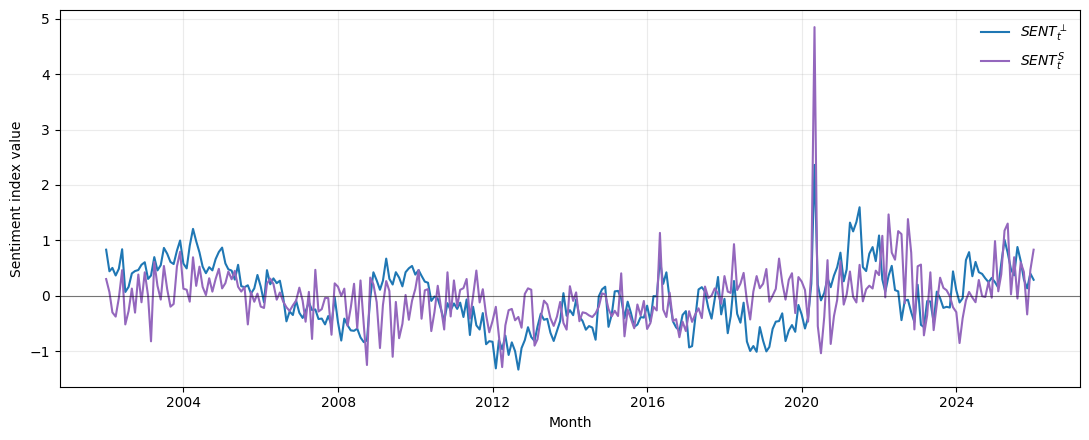

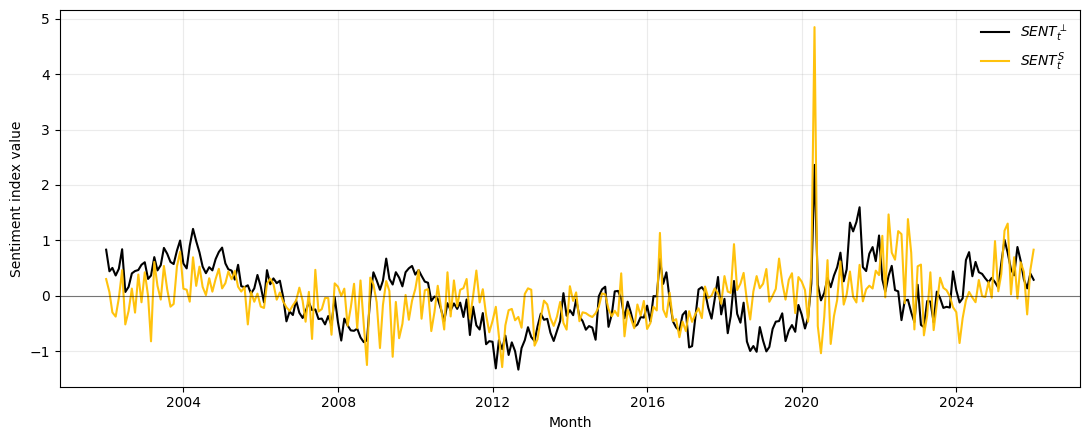

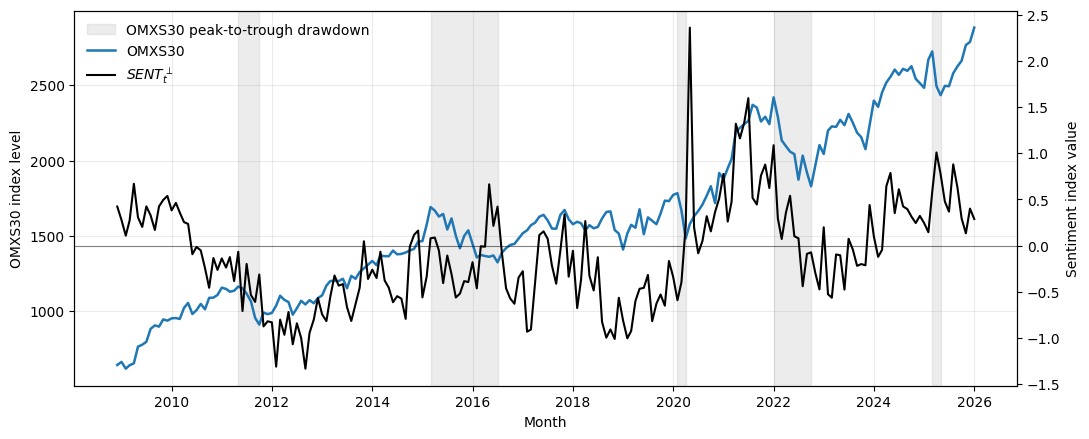

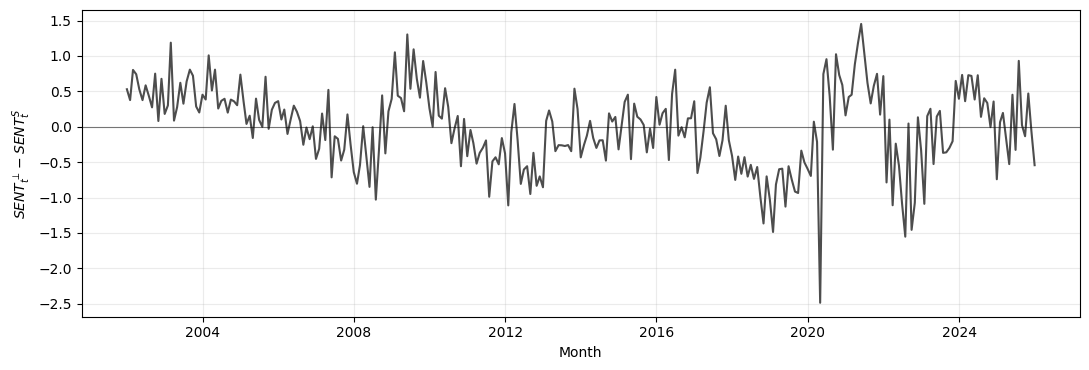

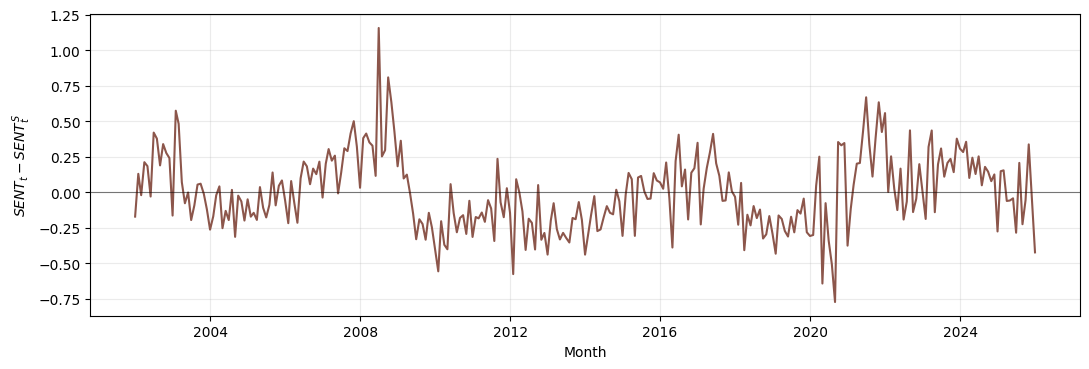

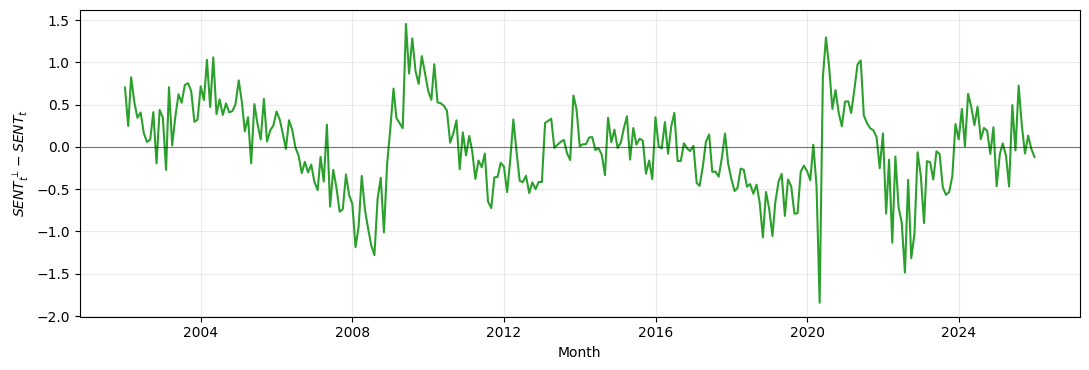

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(sentiment_panel["month_end_date"], sentiment_panel["SENT_ORTH_DIV_PREMIUM"], label="$SENT^{\\perp}_{t}$", color="#1f77b4")
ax.plot(sentiment_panel["month_end_date"], sentiment_panel["SENT_ORTH_SIBLEY_DIV_PREMIUM"], label="$SENT^{S}_{t}$", color="#9467bd", alpha=0.9)
ax.plot(sentiment_panel["month_end_date"], sentiment_panel["SENT_DIV_PREMIUM"], label="$SENT_{t}$", color="#ff7f0e", alpha=0.75)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Month")
ax.set_ylabel("Sentiment index value")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
save_figure("final_sentiment_raw_vs_orth_div_premium_over_time")
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(sentiment_panel["month_end_date"], sentiment_panel["SENT_ORTH_DIV_PREMIUM"], label="$SENT^{\\perp}_{t}$", color="#000000")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Sentiment index value")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
save_figure("final_sentiment_orth_div_premium_over_time")
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(sentiment_panel["month_end_date"], sentiment_panel["SENT_ORTH_DIV_PREMIUM"], label="$SENT^{\\perp}_{t}$", color="#1f77b4")
ax.plot(sentiment_panel["month_end_date"], sentiment_panel["SENT_ORTH_SIBLEY_DIV_PREMIUM"], label="$SENT^{S}_{t}$", color="#9467bd")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Month")
ax.set_ylabel("Sentiment index value")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
save_figure("final_sentiment_sibley_macro_over_time")
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(sentiment_panel["month_end_date"], sentiment_panel["SENT_ORTH_DIV_PREMIUM"], label="$SENT^{\\perp}_{t}$", color="#000000")
ax.plot(sentiment_panel["month_end_date"], sentiment_panel["SENT_ORTH_SIBLEY_DIV_PREMIUM"], label="$SENT^{S}_{t}$", color="#ffbf00", alpha=0.95)
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Month")
ax.set_ylabel("Sentiment index value")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
save_figure("final_sentiment_orth_vs_sibley_black_yellow_over_time")
plt.show()

omxs30_monthly = pd.read_csv(REPO_ROOT / "omxs30_monthly_yfinance.csv", parse_dates=["date"])
omxs30_monthly = (
    omxs30_monthly.assign(
        month_end_date=omxs30_monthly["date"] + pd.offsets.MonthEnd(0),
        adj_close=lambda frame: pd.to_numeric(frame["adj_close"], errors="coerce"),
    )
    .dropna(subset=["month_end_date", "adj_close"])
    .sort_values("month_end_date")
    .reset_index(drop=True)
)
omxs30_sentiment_panel = omxs30_monthly[["month_end_date", "adj_close"]].merge(
    sentiment_panel[["month_end_date", "SENT_ORTH_DIV_PREMIUM"]],
    on="month_end_date",
    how="inner",
).dropna(subset=["adj_close", "SENT_ORTH_DIV_PREMIUM"])

def find_completed_drawdowns(price_frame: pd.DataFrame, *, top_n: int = 5) -> pd.DataFrame:
    data = price_frame[["month_end_date", "adj_close"]].dropna().sort_values("month_end_date")
    if data.empty:
        return pd.DataFrame(columns=["peak_month", "peak_level", "trough_month", "trough_level", "recovery_month", "drawdown_pct"])
    rows = []
    iterator = data.itertuples(index=False)
    first = next(iterator)
    peak_month = first.month_end_date
    peak_level = float(first.adj_close)
    trough_month = first.month_end_date
    trough_level = float(first.adj_close)
    in_drawdown = False
    for row in iterator:
        month = row.month_end_date
        level = float(row.adj_close)
        if level >= peak_level:
            if in_drawdown and trough_level < peak_level:
                rows.append(
                    {
                        "peak_month": peak_month,
                        "peak_level": peak_level,
                        "trough_month": trough_month,
                        "trough_level": trough_level,
                        "recovery_month": month,
                        "drawdown_pct": 100.0 * (trough_level / peak_level - 1.0),
                    }
                )
            peak_month = month
            peak_level = level
            trough_month = month
            trough_level = level
            in_drawdown = False
        else:
            in_drawdown = True
            if level < trough_level:
                trough_month = month
                trough_level = level
    if in_drawdown and trough_level < peak_level:
        rows.append(
            {
                "peak_month": peak_month,
                "peak_level": peak_level,
                "trough_month": trough_month,
                "trough_level": trough_level,
                "recovery_month": pd.NaT,
                "drawdown_pct": 100.0 * (trough_level / peak_level - 1.0),
            }
        )
    return pd.DataFrame(rows).sort_values("drawdown_pct", ascending=True).head(top_n).reset_index(drop=True)

omxs30_drawdowns = find_completed_drawdowns(omxs30_monthly, top_n=5)
save_table(omxs30_sentiment_panel, "final_omxs30_sent_orth_drawdown_panel")
save_table(omxs30_drawdowns, "final_omxs30_drawdown_periods")

fig, ax_left = plt.subplots(figsize=(11, 4.5))
plot_drawdowns = omxs30_drawdowns.sort_values("peak_month").reset_index(drop=True)
for idx, row in plot_drawdowns.iterrows():
    ax_left.axvspan(row["peak_month"], row["trough_month"], color="#bdbdbd", alpha=0.28, label="OMXS30 peak-to-trough drawdown" if idx == 0 else None)
ax_left.plot(omxs30_sentiment_panel["month_end_date"], omxs30_sentiment_panel["adj_close"], label="OMXS30", color="#1f77b4", linewidth=1.8)
ax_left.set_xlabel("Month")
ax_left.set_ylabel("OMXS30 index level")
ax_left.grid(alpha=0.25)
ax_right = ax_left.twinx()
ax_right.plot(omxs30_sentiment_panel["month_end_date"], omxs30_sentiment_panel["SENT_ORTH_DIV_PREMIUM"], label="$SENT^{\\perp}_{t}$", color="#000000", linewidth=1.5)
ax_right.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax_right.set_ylabel("Sentiment index value")
left_handles, left_labels = ax_left.get_legend_handles_labels()
right_handles, right_labels = ax_right.get_legend_handles_labels()
ax_left.legend(left_handles + right_handles, left_labels + right_labels, frameon=False, loc="best")
plt.tight_layout()
save_figure("final_omxs30_sent_orth_drawdowns_over_time")
plt.show()

fig, ax = plt.subplots(figsize=(11, 3.8))
orth_minus_sibley = sentiment_panel["SENT_ORTH_DIV_PREMIUM"] - sentiment_panel["SENT_ORTH_SIBLEY_DIV_PREMIUM"]
ax.plot(sentiment_panel["month_end_date"], orth_minus_sibley, color="#4d4d4d")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Month")
ax.set_ylabel("$SENT^{\\perp}_{t} - SENT^{S}_{t}$")
ax.grid(alpha=0.25)
plt.tight_layout()
save_figure("final_sentiment_orth_minus_sibley_div_premium_over_time")
plt.show()

fig, ax = plt.subplots(figsize=(11, 3.8))
raw_minus_sibley = sentiment_panel["SENT_DIV_PREMIUM"] - sentiment_panel["SENT_ORTH_SIBLEY_DIV_PREMIUM"]
ax.plot(sentiment_panel["month_end_date"], raw_minus_sibley, color="#8c564b")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Month")
ax.set_ylabel("$SENT_{t} - SENT^{S}_{t}$")
ax.grid(alpha=0.25)
plt.tight_layout()
save_figure("final_sentiment_raw_minus_sibley_div_premium_over_time")
plt.show()

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(sentiment_panel["month_end_date"], sentiment_panel["ORTH_minus_RAW_DIV_PREMIUM"], color="#2ca02c")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Month")
ax.set_ylabel("$SENT^{\\perp}_{t} - SENT_{t}$")
ax.grid(alpha=0.25)
plt.tight_layout()
save_figure("final_sentiment_orth_minus_raw_div_premium_over_time")
plt.show()


## Build Lagged Characteristic Portfolios

Portfolio membership is formed using characteristics observed at the end of month `t-1`. Returns are measured from month `t` onward. This avoids same-month look-ahead in the predictive tests.

In [ ]:
PORTFOLIO_OPERATIONALISATION_SPECS = [
    {"sort_variable": "ME", "sort_column": "ME_lag", "sort_type": "continuous", "direction": "low_minus_high", "interpretation": "small_firms"},
    {"sort_variable": "BE_ME", "sort_column": "BE_ME_lag", "sort_type": "continuous", "direction": "mechanical_only", "interpretation": "book_to_market_diagnostic"},
    {"sort_variable": "risk", "sort_column": "risk_lag", "sort_type": "continuous", "direction": "high_minus_low", "interpretation": "high_total_volatility"},
    {"sort_variable": "IVOL_FF3", "sort_column": "IVOL_FF3_lag", "sort_type": "continuous", "direction": "high_minus_low", "interpretation": "high_ff3_idiosyncratic_volatility"},
    {"sort_variable": "age", "sort_column": "age_lag", "sort_type": "continuous", "direction": "low_minus_high", "interpretation": "young_firms"},
    {"sort_variable": "NON_D_PAYER", "sort_column": "NON_D_PAYER_lag", "sort_type": "binary", "direction": "prone_minus_safe", "interpretation": "non_dividend_payers"},
    {"sort_variable": "UNPROFITABLE", "sort_column": "UNPROFITABLE_lag", "sort_type": "binary", "direction": "prone_minus_safe", "interpretation": "non_positive_earnings"},
    {"sort_variable": "E_plus_BE", "sort_column": "E_plus_BE_lag", "sort_type": "continuous", "direction": "low_minus_high", "interpretation": "low_profitability"},
    {"sort_variable": "PPE_A", "sort_column": "PPE_A_lag", "sort_type": "continuous", "direction": "low_minus_high", "interpretation": "low_tangibility"},
    {"sort_variable": "GS", "sort_column": "GS_lag", "sort_type": "continuous", "direction": "high_minus_low", "interpretation": "high_sales_growth"},
    {"sort_variable": "ILLIQ", "sort_column": "ILLIQ_lag", "sort_type": "continuous", "direction": "high_minus_low", "interpretation": "high_amihud_illiquidity"},
    {"sort_variable": "XTURN", "sort_column": "XTURN_lag", "sort_type": "continuous", "direction": "low_minus_high", "interpretation": "low_share_turnover"},
]

portfolio_signal_columns = [spec["sort_variable"] for spec in PORTFOLIO_OPERATIONALISATION_SPECS]
portfolio_lagged_frame = add_lagged_sort_signals(
    artifacts.mart_characteristics_monthly,
    portfolio_signal_columns,
    entity_column="security_id",
    date_column="month_end_date",
)
portfolio_lagged_frame["month_end_date"] = pd.to_datetime(portfolio_lagged_frame["month_end_date"], errors="coerce")

portfolio_operationalisation_metadata = pd.DataFrame(PORTFOLIO_OPERATIONALISATION_SPECS)
portfolio_operationalisation_metadata["mechanical_overlap_warning"] = portfolio_operationalisation_metadata["sort_variable"].isin(["BE_ME", "NON_D_PAYER"])
portfolio_operationalisation_metadata["mechanical_overlap_note"] = np.where(
    portfolio_operationalisation_metadata["mechanical_overlap_warning"],
    "SENT_ORTH_DIV_PREMIUM contains dividend-premium information related to dividend status and valuation; interpret this characteristic cautiously.",
    "",
)
portfolio_lagged_sort_signal_coverage = build_lagged_sort_signal_coverage(
    portfolio_lagged_frame,
    [(spec["sort_variable"], spec["sort_column"]) for spec in PORTFOLIO_OPERATIONALISATION_SPECS],
    value_column="ret",
    date_column="month_end_date",
)

save_table(portfolio_operationalisation_metadata, "final_portfolio_operationalisation_metadata")
save_table(portfolio_lagged_sort_signal_coverage, "final_portfolio_lagged_sort_signal_coverage")
display(portfolio_operationalisation_metadata)
display(portfolio_lagged_sort_signal_coverage.tail())

In [ ]:
def directional_leg_codes(spec: dict[str, str]) -> tuple[str | None, str | None]:
    if spec["sort_type"] == "binary":
        return "PRONE", "SAFE"
    if spec["direction"] == "low_minus_high":
        return "P01", "P10"
    if spec["direction"] == "high_minus_low":
        return "P10", "P01"
    return None, None


portfolio_frames = []
mechanical_spread_frames = []
directional_spread_frames = []
directional_leg_frames = []

for spec in PORTFOLIO_OPERATIONALISATION_SPECS:
    sort_variable = spec["sort_variable"]
    sort_column = spec["sort_column"]
    if sort_column not in portfolio_lagged_frame.columns:
        continue
    if spec["sort_type"] == "binary":
        portfolios = build_binary_flag_portfolios(portfolio_lagged_frame, sort_column=sort_column, value_column="ret")
    else:
        portfolios = build_equal_weight_portfolios(portfolio_lagged_frame, sort_column=sort_column, value_column="ret", n_portfolios=10)
    if portfolios.empty:
        continue
    portfolios.insert(0, "sort_variable", sort_variable)
    portfolios.insert(1, "sort_type", spec["sort_type"])
    portfolios.insert(2, "sentiment_prone_direction", spec["direction"])
    portfolios.insert(3, "sentiment_prone_interpretation", spec["interpretation"])
    portfolios = portfolios.rename(columns={"ew_return": "portfolio_return"})
    portfolio_frames.append(portfolios)

    if spec["sort_type"] == "continuous":
        mechanical = build_long_short_spread(portfolios.rename(columns={"portfolio_return": "ew_return"}))
        if not mechanical.empty:
            mechanical.insert(0, "sort_variable", sort_variable)
            mechanical.insert(1, "sort_type", spec["sort_type"])
            mechanical.insert(2, "sentiment_prone_direction", spec["direction"])
            mechanical.insert(3, "sentiment_prone_interpretation", spec["interpretation"])
            mechanical_spread_frames.append(mechanical)

    long_code, short_code = directional_leg_codes(spec)
    if long_code is None or short_code is None:
        continue
    spread = build_spread_between_portfolios(
        portfolios.rename(columns={"portfolio_return": "ew_return"}),
        long_code=long_code,
        short_code=short_code,
        spread_code="SENTIMENT_PRONE_MINUS_INSENSITIVE",
    )
    if not spread.empty:
        spread.insert(0, "sort_variable", sort_variable)
        spread.insert(1, "sort_type", spec["sort_type"])
        spread.insert(2, "sentiment_prone_direction", spec["direction"])
        spread.insert(3, "sentiment_prone_interpretation", spec["interpretation"])
        spread["return_leg"] = "directional_spread"
        directional_spread_frames.append(spread)

    leg_source = portfolios.loc[portfolios["portfolio_code"].isin([long_code, short_code])].copy()
    if not leg_source.empty:
        leg_source["return_leg"] = np.where(leg_source["portfolio_code"].eq(long_code), "long_leg", "short_leg")
        leg_source["directional_long_code"] = long_code
        leg_source["directional_short_code"] = short_code
        directional_leg_frames.append(leg_source)

portfolio_returns = concat_non_empty(portfolio_frames)
mechanical_spreads = concat_non_empty(mechanical_spread_frames)
directional_spreads = concat_non_empty(directional_spread_frames)
directional_legs = concat_non_empty(directional_leg_frames)

save_table(portfolio_returns, "final_portfolio_returns")
save_table(mechanical_spreads, "final_mechanical_decile_spreads")
save_table(directional_spreads, "final_directional_spreads")
save_table(directional_legs, "final_directional_legs")

display(directional_spreads.head())
display(directional_legs.head())


## Predictive Return Windows and Factor Controls

For each row dated month `t`, the return window is the compounded return from month `t` through `t+h-1`. Portfolio and factor returns are stored in percentage points, so compounding is done in percent-to-percent mode.

In [ ]:
factors_wide = (
    artifacts.fct_factor_monthly.pivot(index="month_end_date", columns="factor_code", values="factor_value")
    .reset_index()
    .sort_values("month_end_date")
)
factors_wide["month_end_date"] = pd.to_datetime(factors_wide["month_end_date"], errors="coerce")
available_controls = [column for column in CONTROL_COLUMNS if column in factors_wide.columns]

factor_long = factors_wide.melt(
    id_vars=["month_end_date"],
    value_vars=available_controls,
    var_name="factor_code",
    value_name="factor_return",
)
factor_windows = build_forward_compounded_return_windows(
    factor_long,
    group_columns=["factor_code"],
    date_column="month_end_date",
    return_column="factor_return",
    horizons=PREDICTIVE_HORIZONS,
    output_column="factor_return_window",
    input_return_unit="percent",
    output_return_unit="percent",
)
factor_windows_wide = (
    factor_windows.pivot_table(
        index=["month_end_date", "return_horizon_months"],
        columns="factor_code",
        values="factor_return_window",
        aggfunc="last",
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

regression_controls = factor_windows_wide.merge(
    sentiment_panel[["country_code", "month_end_date", *SENTIMENT_LEVEL_COLUMNS, *SENTIMENT_REGRESSORS]],
    on="month_end_date",
    how="left",
)

save_table(factors_wide, "final_factor_monthly_wide")
save_table(factor_windows_wide, "final_factor_forward_return_windows")
save_table(regression_controls, "final_regression_controls_by_horizon")
display(regression_controls.tail())

,month_end_date,return_horizon_months,HML,RMRF,SMB,UMD,country_code,SENT_ORTH_DIV_PREMIUM,SENT_ORTH_SIBLEY_DIV_PREMIUM,SENT_DIV_PREMIUM,SENT_ORTH_DIV_PREMIUM_lag,SENT_ORTH_SIBLEY_DIV_PREMIUM_lag,SENT_DIV_PREMIUM_lag
1221,2025-09-30,3,8.334762,2.970602,-13.554111,-3.620741,SWE,0.294451,0.428393,0.371970,0.626545,0.603861,0.377796
1222,2025-10-31,1,6.164514,3.594624,-6.314601,-10.763427,SWE,0.132950,-0.336857,-0.000960,0.294451,0.428393,0.371970
1223,2025-10-31,3,7.106871,5.362109,-17.301205,-1.466753,SWE,0.132950,-0.336857,-0.000960,0.294451,0.428393,0.371970
1224,2025-11-30,1,2.263842,-0.784532,-5.043823,4.388354,SWE,0.401258,0.463194,0.424349,0.132950,-0.336857,-0.000960
1225,2025-12-31,1,-1.345738,2.510382,-7.038302,5.776175,SWE,0.288354,0.831254,0.407129,0.401258,0.463194,0.424349


In [ ]:
directional_spread_windows = build_forward_compounded_return_windows(
    directional_spreads,
    group_columns=["sort_variable", "sort_type", "sentiment_prone_direction", "sentiment_prone_interpretation", "spread_code", "return_leg"],
    date_column="month_end_date",
    return_column="spread_return",
    horizons=PREDICTIVE_HORIZONS,
    output_column="portfolio_return_window",
    input_return_unit="percent",
    output_return_unit="percent",
)

directional_leg_windows = build_forward_compounded_return_windows(
    directional_legs,
    group_columns=["sort_variable", "sort_type", "sentiment_prone_direction", "sentiment_prone_interpretation", "portfolio_code", "return_leg"],
    date_column="month_end_date",
    return_column="portfolio_return",
    horizons=PREDICTIVE_HORIZONS,
    output_column="portfolio_return_window",
    input_return_unit="percent",
    output_return_unit="percent",
)

regression_panel_directional_spreads = directional_spread_windows.merge(
    regression_controls,
    on=["month_end_date", "return_horizon_months"],
    how="left",
)
regression_panel_by_leg = directional_leg_windows.merge(
    regression_controls,
    on=["month_end_date", "return_horizon_months"],
    how="left",
)

return_window_summary = numeric_summary(
    pd.concat(
        [
            regression_panel_directional_spreads.assign(panel="directional_spread"),
            regression_panel_by_leg.assign(panel="by_leg"),
        ],
        ignore_index=True,
    ),
    ["portfolio_return_window", *available_controls],
)

save_table(regression_panel_directional_spreads, "final_predictive_regression_panel_directional_spreads")
save_table(regression_panel_by_leg, "final_predictive_regression_panel_by_leg")
save_table(return_window_summary, "final_predictive_return_window_numeric_summary")

display(return_window_summary)

## Predictive Regressions

The main regression is:

`future portfolio return = alpha + beta SENT_ORTH_DIV_PREMIUM_lag + gamma RMRF + delta SMB + eta HML + theta UMD + error`

The comparison regression replaces `SENT_ORTH_DIV_PREMIUM_lag` with `SENT_DIV_PREMIUM_lag`. This isolates the empirical effect of macro-orthogonalizing the dividend-premium sentiment index.

Both specifications are estimated for 1-, 3-, 6-, and 12-month forward compounded return windows. HAC/Newey-West standard errors are the main inference. Moving-block bootstrap t-statistics are retained as robustness columns in the same output files.


In [ ]:
directional_results = run_regression_suite(
    regression_panel_directional_spreads,
    y_col="portfolio_return_window",
    group_columns=["return_horizon_months", "return_leg", "sort_variable", "sentiment_prone_direction", "sentiment_prone_interpretation"],
    result_set="directional_spread",
)

by_leg_results = run_regression_suite(
    regression_panel_by_leg,
    y_col="portfolio_return_window",
    group_columns=["return_horizon_months", "return_leg", "sort_variable", "portfolio_code", "sentiment_prone_direction", "sentiment_prone_interpretation"],
    result_set="directional_by_leg",
)

save_table(directional_results, "final_predictive_results_directional_spreads_bootstrap")
save_table(hac_only(directional_results), "final_predictive_results_directional_spreads")
save_table(by_leg_results, "final_predictive_results_by_leg_bootstrap")
save_table(hac_only(by_leg_results), "final_predictive_results_by_leg")

summary_directional_by_horizon = sentiment_comparison_summary(
    directional_results,
    ["return_horizon_months"],
)
summary_directional_by_characteristic = sentiment_comparison_summary(
    directional_results,
    ["sort_variable"],
)
summary_by_leg = sentiment_comparison_summary(
    by_leg_results,
    ["return_horizon_months", "return_leg"],
)

raw_vs_orth_directional_comparison = (
    summary_directional_by_characteristic.pivot_table(
        index="sort_variable",
        columns="sentiment_index_label",
        values="mean_expected_signed_t",
        aggfunc="last",
    )
    .reset_index()
)
if {"SENT_ORTH_DIV_PREMIUM", "SENT_DIV_PREMIUM"}.issubset(raw_vs_orth_directional_comparison.columns):
    raw_vs_orth_directional_comparison["orth_minus_raw_mean_expected_signed_t"] = (
        raw_vs_orth_directional_comparison["SENT_ORTH_DIV_PREMIUM"]
        - raw_vs_orth_directional_comparison["SENT_DIV_PREMIUM"]
    )

save_table(summary_directional_by_horizon, "final_summary_directional_by_horizon")
save_table(summary_directional_by_characteristic, "final_summary_directional_by_characteristic")
save_table(summary_by_leg, "final_summary_by_leg")
save_table(raw_vs_orth_directional_comparison, "final_raw_vs_orth_directional_comparison_by_characteristic")

SIBLEY_COMPARISON_LABELS = ["SENT_ORTH_DIV_PREMIUM", "SENT_ORTH_SIBLEY_DIV_PREMIUM"]
sibley_summary_by_horizon = summary_directional_by_horizon.loc[
    summary_directional_by_horizon["sentiment_index_label"].isin(SIBLEY_COMPARISON_LABELS)
].copy()
sibley_summary_by_characteristic = summary_directional_by_characteristic.loc[
    summary_directional_by_characteristic["sentiment_index_label"].isin(SIBLEY_COMPARISON_LABELS)
].copy()
save_table(sibley_summary_by_horizon, "final_sibley_sentiment_comparison_by_horizon")
save_table(sibley_summary_by_characteristic, "final_sibley_sentiment_comparison_by_characteristic")

top_directional = (
    directional_results.loc[directional_results["term"].eq(directional_results["sentiment_regressor"])]
    .sort_values("expected_signed_t_stat", ascending=False)
    .head(40)
)
save_table(top_directional, "final_top_directional_sentiment_tests")

display(summary_directional_by_horizon)
display(summary_directional_by_characteristic.sort_values(["sort_variable", "main_specification_flag"], ascending=[True, False]))
display(raw_vs_orth_directional_comparison)
display(top_directional[["sentiment_index_label", "return_horizon_months", "sort_variable", "coef", "t_stat", "bootstrap_t_stat", "expected_signed_t_stat", "expected_signed_bootstrap_t_stat", "n_obs", "r2", "mechanical_overlap_warning"]])

,return_horizon_months,sentiment_index_label,sentiment_regressor,macro_orthogonalized_flag,main_specification_flag,model_count,mean_coef,mean_hac_t,mean_expected_signed_t,mean_bootstrap_t,mean_expected_signed_bootstrap_t,hac_theory_consistent_5pct_share,bootstrap_theory_consistent_5pct_share,mean_r2,min_n_obs,median_n_obs
0,1,SENT_ORTH_DIV_PREMIUM,SENT_ORTH_DIV_PREMIUM_lag,True,True,11,-0.967866,-1.624876,1.624876,-1.623222,1.623222,0.363636,0.363636,0.289872,240,288.0
1,1,SENT_DIV_PREMIUM,SENT_DIV_PREMIUM_lag,False,False,11,-0.591617,-0.936355,0.936355,-0.862289,0.862289,0.272727,0.272727,0.286228,240,288.0
2,1,SENT_ORTH_SIBLEY_DIV_PREMIUM,SENT_ORTH_SIBLEY_DIV_PREMIUM_lag,True,False,11,-0.497075,-0.750124,0.750124,-0.679984,0.679984,0.090909,0.090909,0.285221,240,288.0
3,3,SENT_ORTH_DIV_PREMIUM,SENT_ORTH_DIV_PREMIUM_lag,True,True,11,-2.042900,-1.462984,1.462984,-1.448999,1.448999,0.363636,0.363636,0.335589,238,286.0
4,3,SENT_DIV_PREMIUM,SENT_DIV_PREMIUM_lag,False,False,11,-1.029509,-0.627052,0.627052,-0.613341,0.613341,0.181818,0.181818,0.323071,238,286.0
5,3,SENT_ORTH_SIBLEY_DIV_PREMIUM,SENT_ORTH_SIBLEY_DIV_PREMIUM_lag,True,False,11,-0.493620,-0.238684,0.238684,-0.238837,0.238837,0.090909,0.090909,0.319221,238,286.0
6,6,SENT_ORTH_DIV_PREMIUM,SENT_ORTH_DIV_PREMIUM_lag,True,True,11,-4.368818,-1.932131,1.932131,-1.907705,1.907705,0.454545,0.454545,0.385456,235,283.0
7,6,SENT_DIV_PREMIUM,SENT_DIV_PREMIUM_lag,False,False,11,-2.631536,-1.168701,1.168701,-1.111643,1.111643,0.090909,0.090909,0.357145,235,283.0
8,6,SENT_ORTH_SIBLEY_DIV_PREMIUM,SENT_ORTH_SIBLEY_DIV_PREMIUM_lag,True,False,11,-1.464435,-0.789103,0.789103,-0.753829,0.753829,0.090909,0.090909,0.349017,235,283.0
9,12,SENT_ORTH_DIV_PREMIUM,SENT_ORTH_DIV_PREMIUM_lag,True,True,11,-7.893080,-2.216832,2.216832,-2.078303,2.078303,0.636364,0.636364,0.477915,229,277.0


,sort_variable,sentiment_index_label,sentiment_regressor,macro_orthogonalized_flag,main_specification_flag,model_count,mean_coef,mean_hac_t,mean_expected_signed_t,mean_bootstrap_t,mean_expected_signed_bootstrap_t,hac_theory_consistent_5pct_share,bootstrap_theory_consistent_5pct_share,mean_r2,min_n_obs,median_n_obs
0,E_plus_BE,SENT_ORTH_DIV_PREMIUM,SENT_ORTH_DIV_PREMIUM_lag,True,True,4,0.118995,-0.025253,0.025253,-0.023762,0.023762,0.00,0.00,0.094336,241,249.5
1,E_plus_BE,SENT_DIV_PREMIUM,SENT_DIV_PREMIUM_lag,False,False,4,1.102650,0.843967,-0.843967,0.789116,-0.789116,0.00,0.00,0.097415,241,249.5
2,E_plus_BE,SENT_ORTH_SIBLEY_DIV_PREMIUM,SENT_ORTH_SIBLEY_DIV_PREMIUM_lag,True,False,4,1.090991,0.884908,-0.884908,0.789319,-0.789319,0.00,0.00,0.097936,241,249.5
3,GS,SENT_ORTH_DIV_PREMIUM,SENT_ORTH_DIV_PREMIUM_lag,True,True,4,-1.575041,-0.782685,0.782685,-0.756902,0.756902,0.00,0.00,0.057948,229,236.5
4,GS,SENT_DIV_PREMIUM,SENT_DIV_PREMIUM_lag,False,False,4,-2.638628,-1.722487,1.722487,-1.567897,1.567897,0.25,0.25,0.070099,229,236.5
5,GS,SENT_ORTH_SIBLEY_DIV_PREMIUM,SENT_ORTH_SIBLEY_DIV_PREMIUM_lag,True,False,4,-1.385631,-1.074308,1.074308,-0.934312,0.934312,0.00,0.00,0.057113,229,236.5
6,ILLIQ,SENT_ORTH_DIV_PREMIUM,SENT_ORTH_DIV_PREMIUM_lag,True,True,4,-1.057235,-0.514944,0.514944,-0.504876,0.504876,0.00,0.00,0.582964,277,284.5
7,ILLIQ,SENT_DIV_PREMIUM,SENT_DIV_PREMIUM_lag,False,False,4,0.123010,0.211118,-0.211118,0.186560,-0.186560,0.00,0.00,0.581858,277,284.5
8,ILLIQ,SENT_ORTH_SIBLEY_DIV_PREMIUM,SENT_ORTH_SIBLEY_DIV_PREMIUM_lag,True,False,4,0.458821,0.475372,-0.475372,0.406952,-0.406952,0.00,0.00,0.582039,277,284.5
9,IVOL_FF3,SENT_ORTH_DIV_PREMIUM,SENT_ORTH_DIV_PREMIUM_lag,True,True,4,-9.499581,-3.366734,3.366734,-3.370362,3.370362,1.00,1.00,0.523470,277,284.5


sentiment_index_label,sort_variable,SENT_DIV_PREMIUM,SENT_ORTH_DIV_PREMIUM,SENT_ORTH_SIBLEY_DIV_PREMIUM,orth_minus_raw_mean_expected_signed_t
0,E_plus_BE,-0.843967,0.025253,-0.884908,0.869220
1,GS,1.722487,0.782685,1.074308,-0.939802
2,ILLIQ,-0.211118,0.514944,-0.475372,0.726062
3,IVOL_FF3,1.034074,3.366734,0.430742,2.332660
4,ME,1.133113,2.204993,0.953648,1.071880
5,NON_D_PAYER,-0.010978,2.594496,0.109341,2.605474
6,PPE_A,2.961087,3.971405,2.898909,1.010319
7,UNPROFITABLE,0.044580,1.800812,0.089921,1.756232
8,XTURN,1.929142,-0.587520,1.143228,-2.516663
9,age,1.486713,1.278882,0.388806,-0.207831


,sentiment_index_label,return_horizon_months,sort_variable,coef,t_stat,bootstrap_t_stat,expected_signed_t_stat,expected_signed_bootstrap_t_stat,n_obs,r2,mechanical_overlap_warning
235,SENT_ORTH_DIV_PREMIUM,12,PPE_A,-15.272567,-4.832386,-4.374901,4.832386,4.374901,277,0.291304,False
259,SENT_ORTH_DIV_PREMIUM,12,risk,-19.654022,-4.434572,-4.183523,4.434572,4.183523,277,0.634300,False
193,SENT_ORTH_DIV_PREMIUM,6,risk,-12.078322,-4.296106,-4.254727,4.296106,4.254727,283,0.582418,False
169,SENT_ORTH_DIV_PREMIUM,6,PPE_A,-8.337796,-4.205708,-4.111234,4.205708,4.111234,283,0.207336,False
151,SENT_ORTH_DIV_PREMIUM,6,IVOL_FF3,-11.735131,-4.052724,-4.024316,4.052724,4.024316,283,0.533607,False
103,SENT_ORTH_DIV_PREMIUM,3,PPE_A,-4.455361,-3.860902,-3.785542,3.860902,3.785542,286,0.143375,False
217,SENT_ORTH_DIV_PREMIUM,12,IVOL_FF3,-18.422159,-3.754081,-3.756899,3.754081,3.756899,277,0.660122,False
127,SENT_ORTH_DIV_PREMIUM,3,risk,-6.493915,-3.559900,-3.475973,3.559900,3.475973,286,0.519546,False
61,SENT_ORTH_DIV_PREMIUM,1,risk,-2.600736,-3.503742,-3.506895,3.503742,3.506895,288,0.509012,False
697,SENT_DIV_PREMIUM,6,PPE_A,-6.015937,-3.402047,-3.282434,3.402047,3.282434,283,0.125776,False


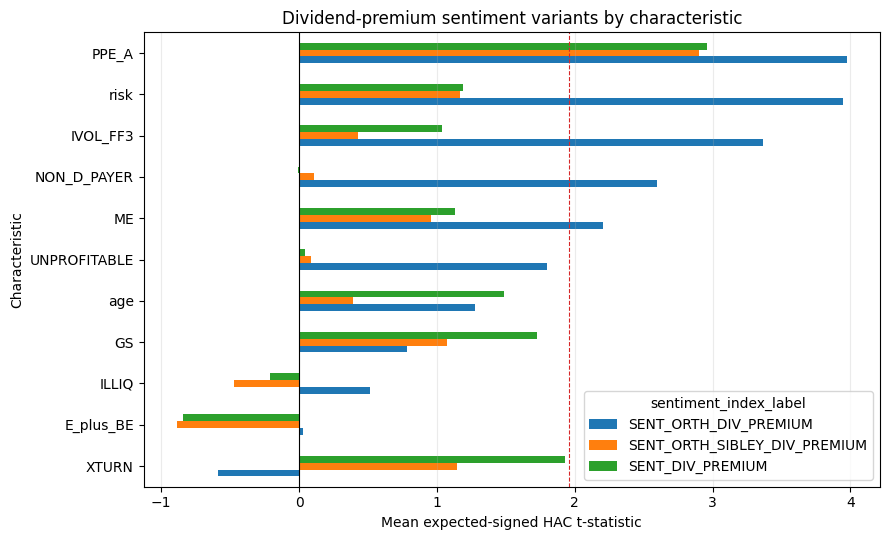

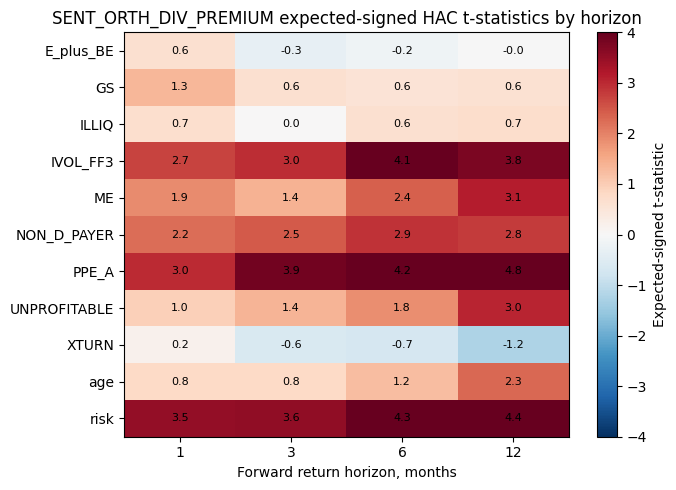

In [ ]:
if not summary_directional_by_characteristic.empty:
    plot_data = summary_directional_by_characteristic.copy()
    pivot = plot_data.pivot_table(
        index="sort_variable",
        columns="sentiment_index_label",
        values="mean_expected_signed_t",
        aggfunc="last",
    ).sort_values("SENT_ORTH_DIV_PREMIUM", ascending=True)
    fig, ax = plt.subplots(figsize=(9, 5.5))
    plot_columns = [column for column in ["SENT_ORTH_DIV_PREMIUM", "SENT_ORTH_SIBLEY_DIV_PREMIUM", "SENT_DIV_PREMIUM"] if column in pivot.columns]
    plot_frame = pivot[plot_columns].rename(
        columns={
            "SENT_ORTH_DIV_PREMIUM": "$SENT^{\\perp}_{t}$",
            "SENT_ORTH_SIBLEY_DIV_PREMIUM": "$SENT^{S}_{t}$",
            "SENT_DIV_PREMIUM": "$SENT_{t}$",
        }
    )
    plot_frame.plot.barh(ax=ax)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(1.96, color="#D62728", linewidth=0.8, linestyle="--", label="1.96")
    ax.set_xlabel("Mean expected-signed HAC t-statistic")
    ax.set_ylabel("Characteristic")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    save_figure("final_raw_vs_orth_mean_expected_signed_t_by_characteristic")
    plt.show()

sentiment_terms = directional_results.loc[directional_results["term"].eq(directional_results["sentiment_regressor"])].copy()
main_terms = sentiment_terms.loc[sentiment_terms["sentiment_regressor"].eq(MAIN_SENTIMENT_REGRESSOR)].copy()
if not main_terms.empty:
    heat = main_terms.pivot_table(
        index="sort_variable",
        columns="return_horizon_months",
        values="expected_signed_t_stat",
        aggfunc="mean",
    )
    fig, ax = plt.subplots(figsize=(7, 5))
    image = ax.imshow(heat.values, aspect="auto", cmap="RdBu_r", vmin=-4, vmax=4)
    ax.set_xticks(range(len(heat.columns)), labels=heat.columns)
    ax.set_yticks(range(len(heat.index)), labels=heat.index)
    ax.set_xlabel("Forward return horizon, months")
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            value = heat.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.1f}", ha="center", va="center", fontsize=8)
    fig.colorbar(image, ax=ax, label="Expected-signed t-statistic")
    plt.tight_layout()
    save_figure("final_directional_expected_signed_t_heatmap")
    plt.show()

## Persistence Robustness Checks

These checks address the concern that a persistent monthly sentiment index can reuse the same sentiment episode across adjacent observations, especially when forward return windows overlap. They apply only to `SENT_ORTH_DIV_PREMIUM`, the baseline specification used in this thesis.

- Non-overlapping horizon regressions keep every `h`th observation for an `h`-month return horizon and run all calendar offsets.
- Sentiment-innovation regressions replace the persistent sentiment level with the AR(1) residual innovation in the orthogonalized sentiment index.


In [ ]:
BASELINE_SENTIMENT_SPECS = [spec for spec in SENTIMENT_SPECS if spec["sentiment_regressor"] == MAIN_SENTIMENT_REGRESSOR]
INNOVATION_REGRESSOR = "SENT_ORTH_DIV_PREMIUM_innovation_lag"
INNOVATION_SENTIMENT_SPECS = [
    {
        "sentiment_index_family": "dividend_premium_macro_adjusted_fixed_pca_innovation",
        "sentiment_index_label": "SENT_ORTH_DIV_PREMIUM_INNOVATION",
        "sentiment_level_column": "SENT_ORTH_DIV_PREMIUM_innovation",
        "sentiment_regressor": INNOVATION_REGRESSOR,
        "macro_orthogonalized_flag": True,
        "main_specification_flag": False,
    }
]


def sentiment_term_rows(results: pd.DataFrame) -> pd.DataFrame:
    if results is None or results.empty:
        return pd.DataFrame()
    return results.loc[results["term"].eq(results["sentiment_regressor"])].copy()


def summarize_nonoverlap_results(results: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    terms = sentiment_term_rows(results)
    if terms.empty:
        return pd.DataFrame(), pd.DataFrame()
    group_columns = [
        "return_horizon_months",
        "sort_variable",
        "sentiment_prone_direction",
        "sentiment_prone_interpretation",
    ]
    by_characteristic = (
        terms.groupby(group_columns, dropna=False)
        .agg(
            offset_count=("nonoverlap_offset", "nunique"),
            estimated_model_count=("coef", "count"),
            median_coef=("coef", "median"),
            median_hac_t=("t_stat", "median"),
            median_expected_signed_t=("expected_signed_t_stat", "median"),
            median_bootstrap_t=("bootstrap_t_stat", "median"),
            median_expected_signed_bootstrap_t=("expected_signed_bootstrap_t_stat", "median"),
            theory_consistent_sign_share=("theory_consistent_sign", "mean"),
            hac_theory_consistent_5pct_share=("theory_consistent_hac_5pct", "mean"),
            bootstrap_theory_consistent_5pct_share=("theory_consistent_bootstrap_5pct", "mean"),
            min_n_obs=("n_obs", "min"),
            median_n_obs=("n_obs", "median"),
            median_r2=("r2", "median"),
        )
        .reset_index()
        .sort_values(["return_horizon_months", "sort_variable"])
    )
    by_horizon = (
        terms.groupby(["return_horizon_months"], dropna=False)
        .agg(
            characteristic_count=("sort_variable", "nunique"),
            offset_model_count=("coef", "count"),
            median_coef=("coef", "median"),
            median_hac_t=("t_stat", "median"),
            median_expected_signed_t=("expected_signed_t_stat", "median"),
            median_bootstrap_t=("bootstrap_t_stat", "median"),
            median_expected_signed_bootstrap_t=("expected_signed_bootstrap_t_stat", "median"),
            theory_consistent_sign_share=("theory_consistent_sign", "mean"),
            hac_theory_consistent_5pct_share=("theory_consistent_hac_5pct", "mean"),
            bootstrap_theory_consistent_5pct_share=("theory_consistent_bootstrap_5pct", "mean"),
            min_n_obs=("n_obs", "min"),
            median_n_obs=("n_obs", "median"),
            median_r2=("r2", "median"),
        )
        .reset_index()
        .sort_values("return_horizon_months")
    )
    return by_characteristic, by_horizon


def build_nonoverlap_panel(panel: pd.DataFrame, horizons: tuple[int, ...]) -> pd.DataFrame:
    if panel is None or panel.empty:
        return pd.DataFrame()
    base = panel.copy()
    base["month_end_date"] = pd.to_datetime(base["month_end_date"], errors="coerce")
    month_index = pd.Series(
        range(base["month_end_date"].dropna().nunique()),
        index=sorted(base["month_end_date"].dropna().unique()),
    )
    base["nonoverlap_month_index"] = base["month_end_date"].map(month_index).astype("Int64")
    frames = []
    for horizon in horizons:
        horizon = int(horizon)
        horizon_base = base.loc[base["return_horizon_months"].eq(horizon)].copy()
        for offset in range(horizon):
            sample = horizon_base.loc[horizon_base["nonoverlap_month_index"].mod(horizon).eq(offset)].copy()
            if sample.empty:
                continue
            duplicate_keys = ["return_horizon_months", "sort_variable", "month_end_date"]
            if sample.duplicated(duplicate_keys).any():
                duplicates = sample.loc[sample.duplicated(duplicate_keys, keep=False), duplicate_keys].head()
                raise ValueError(f"Non-overlap sample has duplicated regression rows: {duplicates.to_dict('records')}")
            sample["nonoverlap_offset"] = offset
            sample["nonoverlap_offset_label"] = f"offset_{offset:02d}_of_{horizon:02d}"
            frames.append(sample)
    return concat_non_empty(frames)


nonoverlap_panel = build_nonoverlap_panel(regression_panel_directional_spreads, PREDICTIVE_HORIZONS)
nonoverlap_results = run_regression_suite(
    nonoverlap_panel,
    y_col="portfolio_return_window",
    group_columns=[
        "return_horizon_months",
        "nonoverlap_offset",
        "nonoverlap_offset_label",
        "return_leg",
        "sort_variable",
        "sentiment_prone_direction",
        "sentiment_prone_interpretation",
    ],
    result_set="nonoverlap_directional_spread",
    sentiment_specs=BASELINE_SENTIMENT_SPECS,
)
nonoverlap_summary_by_characteristic, nonoverlap_summary_by_horizon = summarize_nonoverlap_results(nonoverlap_results)

save_table(nonoverlap_results, "final_nonoverlap_horizon_results_bootstrap")
save_table(hac_only(nonoverlap_results), "final_nonoverlap_horizon_results")
save_table(nonoverlap_summary_by_characteristic, "final_nonoverlap_horizon_summary_by_characteristic")
save_table(nonoverlap_summary_by_horizon, "final_nonoverlap_horizon_summary_by_horizon")

nonoverlap_offset_check = (
    nonoverlap_panel.groupby("return_horizon_months", dropna=False)["nonoverlap_offset"]
    .nunique()
    .rename("offset_count")
    .reset_index()
)
print("Non-overlap offset check")
display(nonoverlap_offset_check)
display(nonoverlap_summary_by_horizon)


Non-overlap offset check


,return_horizon_months,offset_count
0,1,1
1,3,3
2,6,6
3,12,12


,return_horizon_months,characteristic_count,offset_model_count,median_coef,median_hac_t,median_expected_signed_t,median_bootstrap_t,median_expected_signed_bootstrap_t,theory_consistent_sign_share,hac_theory_consistent_5pct_share,bootstrap_theory_consistent_5pct_share,min_n_obs,median_n_obs,median_r2
0,1,11,11,-0.628773,-1.326473,1.326473,-1.284742,1.284742,1.000000,0.363636,0.363636,240,288.0,0.264318
1,3,11,33,-1.765592,-1.344331,1.344331,-1.283406,1.283406,0.757576,0.393939,0.333333,79,95.0,0.442492
2,6,11,66,-3.551014,-1.420791,1.420791,-1.138639,1.138639,0.833333,0.393939,0.303030,39,47.0,0.494167
3,12,11,132,-7.232029,-2.422031,2.422031,-1.396608,1.396608,0.856061,0.553030,0.409091,19,23.0,0.610960


In [ ]:
sentiment_innovation_monthly = sentiment_panel[
    ["country_code", "month_end_date", "SENT_ORTH_DIV_PREMIUM", "SENT_ORTH_DIV_PREMIUM_lag"]
].copy()
ar1_sample = sentiment_innovation_monthly.dropna(subset=["SENT_ORTH_DIV_PREMIUM", "SENT_ORTH_DIV_PREMIUM_lag"]).copy()
y = ar1_sample["SENT_ORTH_DIV_PREMIUM"].to_numpy(dtype=float)
x_lag = ar1_sample["SENT_ORTH_DIV_PREMIUM_lag"].to_numpy(dtype=float)
x = np.column_stack([np.ones(len(ar1_sample)), x_lag])
beta, *_ = np.linalg.lstsq(x, y, rcond=None)
ar1_sample["SENT_ORTH_DIV_PREMIUM_fitted"] = x @ beta
ar1_sample["SENT_ORTH_DIV_PREMIUM_innovation"] = y - ar1_sample["SENT_ORTH_DIV_PREMIUM_fitted"]
ss_total = float(((y - y.mean()) @ (y - y.mean())))
ss_resid = float((ar1_sample["SENT_ORTH_DIV_PREMIUM_innovation"].to_numpy(dtype=float) @ ar1_sample["SENT_ORTH_DIV_PREMIUM_innovation"].to_numpy(dtype=float)))
ar1_r2 = np.nan if ss_total == 0 else 1.0 - ss_resid / ss_total

sentiment_innovation_monthly = sentiment_innovation_monthly.merge(
    ar1_sample[
        [
            "month_end_date",
            "SENT_ORTH_DIV_PREMIUM_fitted",
            "SENT_ORTH_DIV_PREMIUM_innovation",
        ]
    ],
    on="month_end_date",
    how="left",
)
sentiment_innovation_monthly = sentiment_innovation_monthly.sort_values("month_end_date").reset_index(drop=True)
sentiment_innovation_monthly["SENT_ORTH_DIV_PREMIUM_innovation_lag"] = sentiment_innovation_monthly[
    "SENT_ORTH_DIV_PREMIUM_innovation"
].shift(1)

innovation_diagnostics = pd.DataFrame(
    [
        {
            "sentiment_index_label": "SENT_ORTH_DIV_PREMIUM",
            "model": "SENT_t_on_intercept_and_SENT_lag",
            "intercept": beta[0],
            "rho": beta[1],
            "r2": ar1_r2,
            "n_obs": len(ar1_sample),
            "innovation_mean": ar1_sample["SENT_ORTH_DIV_PREMIUM_innovation"].mean(),
            "innovation_std": ar1_sample["SENT_ORTH_DIV_PREMIUM_innovation"].std(),
            "innovation_min": ar1_sample["SENT_ORTH_DIV_PREMIUM_innovation"].min(),
            "innovation_max": ar1_sample["SENT_ORTH_DIV_PREMIUM_innovation"].max(),
            "lagged_innovation_count": int(sentiment_innovation_monthly["SENT_ORTH_DIV_PREMIUM_innovation_lag"].notna().sum()),
        }
    ]
)

innovation_panel = regression_panel_directional_spreads.merge(
    sentiment_innovation_monthly[["month_end_date", "SENT_ORTH_DIV_PREMIUM_innovation_lag"]],
    on="month_end_date",
    how="left",
)
innovation_results = run_regression_suite(
    innovation_panel,
    y_col="portfolio_return_window",
    group_columns=[
        "return_horizon_months",
        "return_leg",
        "sort_variable",
        "sentiment_prone_direction",
        "sentiment_prone_interpretation",
    ],
    result_set="sentiment_innovation_directional_spread",
    sentiment_specs=INNOVATION_SENTIMENT_SPECS,
)
innovation_summary_by_characteristic = sentiment_comparison_summary(innovation_results, ["sort_variable"])
innovation_summary_by_horizon = sentiment_comparison_summary(innovation_results, ["return_horizon_months"])

save_table(sentiment_innovation_monthly, "final_sentiment_innovation_monthly")
save_table(innovation_diagnostics, "final_sentiment_innovation_ar1_diagnostics")
save_table(innovation_results, "final_sentiment_innovation_results_bootstrap")
save_table(hac_only(innovation_results), "final_sentiment_innovation_results")
save_table(innovation_summary_by_characteristic, "final_sentiment_innovation_summary_by_characteristic")
save_table(innovation_summary_by_horizon, "final_sentiment_innovation_summary_by_horizon")

display(innovation_diagnostics)
display(innovation_summary_by_horizon)


,sentiment_index_label,model,intercept,rho,r2,n_obs,innovation_mean,innovation_std,innovation_min,innovation_max,lagged_innovation_count
0,SENT_ORTH_DIV_PREMIUM,SENT_t_on_intercept_and_SENT_lag,-0.004942,0.793756,0.634475,288,4.471732e-17,0.336583,-1.67142,2.192725,287


,return_horizon_months,sentiment_index_label,sentiment_regressor,macro_orthogonalized_flag,main_specification_flag,model_count,mean_coef,mean_hac_t,mean_expected_signed_t,mean_bootstrap_t,mean_expected_signed_bootstrap_t,hac_theory_consistent_5pct_share,bootstrap_theory_consistent_5pct_share,mean_r2,min_n_obs,median_n_obs
0,1,SENT_ORTH_DIV_PREMIUM_INNOVATION,SENT_ORTH_DIV_PREMIUM_innovation_lag,True,False,11,-0.871554,-0.841805,0.841805,-0.794804,0.794804,0.181818,0.181818,0.295912,240,287.0
1,3,SENT_ORTH_DIV_PREMIUM_INNOVATION,SENT_ORTH_DIV_PREMIUM_innovation_lag,True,False,11,-1.193076,-0.886965,0.886965,-0.877744,0.877744,0.000000,0.000000,0.319309,238,285.0
2,6,SENT_ORTH_DIV_PREMIUM_INNOVATION,SENT_ORTH_DIV_PREMIUM_innovation_lag,True,False,11,-2.533940,-1.224856,1.224856,-1.199515,1.199515,0.272727,0.272727,0.346179,235,282.0
3,12,SENT_ORTH_DIV_PREMIUM_INNOVATION,SENT_ORTH_DIV_PREMIUM_innovation_lag,True,False,11,-4.001085,-1.269564,1.269564,-1.270856,1.270856,0.181818,0.181818,0.415576,229,276.0


In [ ]:
def persistence_rows_from_terms(terms: pd.DataFrame, method: str) -> pd.DataFrame:
    if terms is None or terms.empty:
        return pd.DataFrame()
    out = terms.copy()
    return pd.DataFrame(
        {
            "robustness_method": method,
            "return_horizon_months": out["return_horizon_months"],
            "sort_variable": out["sort_variable"],
            "sentiment_prone_direction": out["sentiment_prone_direction"],
            "sentiment_prone_interpretation": out["sentiment_prone_interpretation"],
            "coef": out["coef"],
            "expected_signed_hac_t_stat": out["expected_signed_t_stat"],
            "expected_signed_bootstrap_t_stat": out["expected_signed_bootstrap_t_stat"],
            "theory_consistent_sign_flag": out["theory_consistent_sign"],
            "theory_consistent_sign_share": out["theory_consistent_sign"].astype(float),
            "theory_consistent_hac_5pct_share": out["theory_consistent_hac_5pct"].astype(float),
            "theory_consistent_bootstrap_5pct_share": out["theory_consistent_bootstrap_5pct"].astype(float),
            "n_obs": out["n_obs"],
            "model_count": 1,
        }
    )


baseline_terms = sentiment_term_rows(directional_results)
baseline_terms = baseline_terms.loc[baseline_terms["sentiment_regressor"].eq(MAIN_SENTIMENT_REGRESSOR)].copy()
innovation_terms = sentiment_term_rows(innovation_results)

nonoverlap_persistence = pd.DataFrame()
if not nonoverlap_summary_by_characteristic.empty:
    nonoverlap_persistence = pd.DataFrame(
        {
            "robustness_method": "nonoverlapping_horizon_median_offset",
            "return_horizon_months": nonoverlap_summary_by_characteristic["return_horizon_months"],
            "sort_variable": nonoverlap_summary_by_characteristic["sort_variable"],
            "sentiment_prone_direction": nonoverlap_summary_by_characteristic["sentiment_prone_direction"],
            "sentiment_prone_interpretation": nonoverlap_summary_by_characteristic["sentiment_prone_interpretation"],
            "coef": nonoverlap_summary_by_characteristic["median_coef"],
            "expected_signed_hac_t_stat": nonoverlap_summary_by_characteristic["median_expected_signed_t"],
            "expected_signed_bootstrap_t_stat": nonoverlap_summary_by_characteristic["median_expected_signed_bootstrap_t"],
            "theory_consistent_sign_flag": nonoverlap_summary_by_characteristic["theory_consistent_sign_share"].ge(0.5),
            "theory_consistent_sign_share": nonoverlap_summary_by_characteristic["theory_consistent_sign_share"],
            "theory_consistent_hac_5pct_share": nonoverlap_summary_by_characteristic["hac_theory_consistent_5pct_share"],
            "theory_consistent_bootstrap_5pct_share": nonoverlap_summary_by_characteristic["bootstrap_theory_consistent_5pct_share"],
            "n_obs": nonoverlap_summary_by_characteristic["median_n_obs"],
            "model_count": nonoverlap_summary_by_characteristic["estimated_model_count"],
        }
    )

persistence_robustness_summary = concat_non_empty(
    [
        persistence_rows_from_terms(baseline_terms, "overlapping_baseline"),
        nonoverlap_persistence,
        persistence_rows_from_terms(innovation_terms, "sentiment_ar1_innovation"),
    ]
).sort_values(["return_horizon_months", "sort_variable", "robustness_method"])

save_table(persistence_robustness_summary, "final_persistence_robustness_summary")
display(persistence_robustness_summary.head(30))


,robustness_method,return_horizon_months,sort_variable,sentiment_prone_direction,sentiment_prone_interpretation,coef,expected_signed_hac_t_stat,expected_signed_bootstrap_t_stat,theory_consistent_sign_flag,theory_consistent_sign_share,theory_consistent_hac_5pct_share,theory_consistent_bootstrap_5pct_share,n_obs,model_count
44,nonoverlapping_horizon_median_offset,1,E_plus_BE,low_minus_high,low_profitability,-0.437066,0.636196,0.616381,True,1.0,0.0,0.0,256.0,1
0,overlapping_baseline,1,E_plus_BE,low_minus_high,low_profitability,-0.437066,0.636196,0.616381,True,1.0,0.0,0.0,256.0,1
88,sentiment_ar1_innovation,1,E_plus_BE,low_minus_high,low_profitability,0.179121,-0.314787,-0.286590,False,0.0,0.0,0.0,255.0,1
45,nonoverlapping_horizon_median_offset,1,GS,high_minus_low,high_sales_growth,-0.797423,1.326473,1.284742,True,1.0,0.0,0.0,240.0,1
1,overlapping_baseline,1,GS,high_minus_low,high_sales_growth,-0.797423,1.326473,1.284742,True,1.0,0.0,0.0,240.0,1
89,sentiment_ar1_innovation,1,GS,high_minus_low,high_sales_growth,-2.725414,2.440487,2.224065,True,1.0,1.0,1.0,240.0,1
46,nonoverlapping_horizon_median_offset,1,ILLIQ,high_minus_low,high_amihud_illiquidity,-0.303650,0.665173,0.661523,True,1.0,0.0,0.0,288.0,1
2,overlapping_baseline,1,ILLIQ,high_minus_low,high_amihud_illiquidity,-0.303650,0.665173,0.661523,True,1.0,0.0,0.0,288.0,1
90,sentiment_ar1_innovation,1,ILLIQ,high_minus_low,high_amihud_illiquidity,-0.748259,0.925278,0.908075,True,1.0,0.0,0.0,287.0,1
47,nonoverlapping_horizon_median_offset,1,IVOL_FF3,high_minus_low,high_ff3_idiosyncratic_volatility,-2.242455,2.694348,2.691772,True,1.0,1.0,1.0,288.0,1


## Output Inventory

This table lists the files produced by this notebook for this thesis. The broader audit and model-selection outputs are archived under `archive/outputs`.

In [ ]:
output_inventory = pd.DataFrame(
    [{"file": path.name, "bytes": path.stat().st_size} for path in sorted(OUTPUT_DIR.glob("*"))]
)
save_table(output_inventory, "final_output_inventory")
display(output_inventory)

,file,bytes
0,artifact_shapes.csv,186
1,final_directional_expected_signed_t_heatmap.png,75050
2,final_directional_legs.csv,676936
3,final_directional_spreads.csv,462496
4,final_dividend_premium_proxy_diagnostics.csv,44393
...,...,...
66,final_sibley_sentiment_comparison_by_horizon.csv,2225
67,final_summary_by_leg.csv,5317
68,final_summary_directional_by_characteristic.csv,7068
69,final_summary_directional_by_horizon.csv,3110
